In [54]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV


from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [40]:
df = pd.read_csv('df_cafes_with_price.csv')
df['log_review_count'] = np.log(df['dgis_org_review_count']) #для нового таргета
df = df.drop(["name", 'brand','dgis_org_rating', 'dgis_org_review_count', 'dgis_general_review_count_with_stars'], axis = 1)

df.head()

,type,cuisine,website,lat,lon,dgis_general_rating,city,direct_competitors_500m,direct_competitors_1000m,direct_competitors_100m,...,parks_1000m,nearest_park,nearest_park_name,res_buildings_density_1000m,afisha_average_bill,afisha_open_date,afisha_work_time,afisha_delivery,afisha_parking,log_review_count
0,bar,NaN,1,55.765574,37.638976,4.9,Москва,0,0,0,...,27,247.780090,Сквер «Огородная слобода»,132.416913,До 1000 рублей,NaN,"пн-пт 8.00–22.00, сб-вс 9.00–22.00",True,False,5.529429
1,cafe,vietnamese,0,55.768280,37.644618,3.5,Москва,1,3,0,...,32,42.032631,(без названия),113.954939,1000–3000 рублей,NaN,"пн-пт 11.00–23.00, сб 12.00–23.00",False,False,5.099866
2,cafe,coffee_shop,1,55.738811,37.653006,2.4,Москва,20,51,2,...,8,91.996504,(без названия),56.659160,1000–3000 рублей,NaN,"пн-чт 12.00–0.00, пт 12.00–2.00, сб 14.00–2.00...",False,True,9.296426
3,restaurant,japanese,1,55.728517,37.679155,4.9,Москва,0,0,0,...,7,509.973891,(без названия),46.791553,1000–3000 рублей,NaN,пн-вс 12.00–0.00,True,True,10.123466
4,restaurant,russian,1,55.732211,37.665123,4.1,Москва,0,0,0,...,9,191.115200,(без названия),69.709865,1000–3000 рублей,3/31/2016 0:00,пн-вс 10.30–23.00,True,True,8.263848


In [53]:
df['indirect_competitors_1000m']

0       408
1       293
2       149
3        29
4        85
       ... 
9213      0
9214      0
9215      0
9216      0
9217      0
Name: indirect_competitors_1000m, Length: 9218, dtype: int64

In [12]:
df.dgis_general_rating

0       4.9
1       3.5
2       2.4
3       4.9
4       4.1
       ... 
9213    3.1
9214    3.7
9215    4.1
9216    4.4
9217    4.7
Name: dgis_general_rating, Length: 9218, dtype: float64

# Таргет - рейтинг заведения

In [42]:
y = df['dgis_general_rating']
X = df.drop(columns=['dgis_general_rating'])
# логарифмы
X['log_direct_comp'] = np.log1p(X['direct_competitors_500m'])

# агрегаты
X['direct_comp_mean'] = X[
    ['direct_competitors_100m', 'direct_competitors_500m', 'direct_competitors_1000m']
].mean(axis=1)

# конкуренция
X['competition_ratio'] = X['direct_competitors_500m'] / (X['indirect_competitors_500m'] + 1)

# центр
X['is_centre'] = (X['distance_to_city_centre'] < X['distance_to_city_centre'].median()).astype(int)

# гео
X['geo_feature'] = X['lat'] * X['lon']
X = pd.get_dummies(X, columns=['type', 'cuisine', 'city'], drop_first=True)

name_cols = [
    'nearest_museum_name',
    'nearest_theatre_name',
    'nearest_gallery_name',
    'nearest_park_name'
]

for col in name_cols:
    freq_map = X[col].value_counts()
    X[col + '_freq'] = X[col].map(freq_map)

# website отдельно (можно просто длину)
X['website_len'] = X['website'].fillna('').astype(str).apply(len)
# удаляем оригиналы
X = X.drop(columns=[
    'website',
    'nearest_museum_name',
    'nearest_theatre_name',
    'nearest_gallery_name',
    'nearest_park_name'
], errors='ignore')

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:

cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

params = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [10, 15, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring='r2',   
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print(search.best_params_)
print(search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[CV] END model__max_depth=30, model__max_features=None, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=  28.0s
[CV] END model__max_depth=30, model__max_features=None, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=  28.4s
[CV] END model__max_depth=30, model__max_features=None, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=  28.5s
[CV] END model__max_depth=30, model__max_features=None, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=  28.6s
[CV] END model__max_depth=30, model__max_features=None, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=  28.8s
[CV] END model__max_depth=15, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=  23.6s
[CV] END model__max_depth=15, model__max_features=None, model__min_sam

Топ-20 самых важных признаков:
                        feature  importance
0              log_review_count    0.128914
1                type_fast_food    0.049864
2      nearest_bus_trolley_stop    0.030746
3                  nearest_park    0.027444
4       nearest_railway_station    0.027259
5         nearest_metro_station    0.026703
6                 hhindex_1000m    0.025261
7       nearest_business_centre    0.024736
8                  hhindex_500m    0.022765
9                           lat    0.022732
10               nearest_museum    0.022542
11   indirect_competitors_1000m    0.022090
12              nearest_theatre    0.021843
13                          lon    0.021079
14  res_buildings_density_1000m    0.019812
15      bus_trolley_stops_1000m    0.019098
16              nearest_gallery    0.018928
17    indirect_competitors_100m    0.018021
18  schools_kindergartens_1000m    0.017612
19                  geo_feature    0.016970


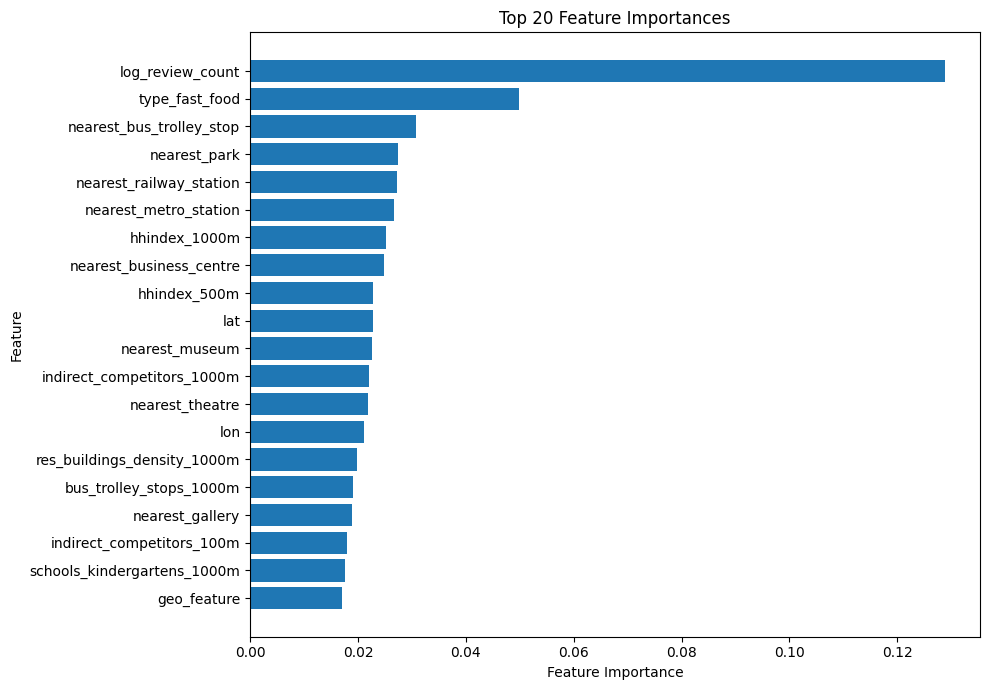

In [ ]:
preprocessor = best_model.named_steps['preprocessor']
model = best_model.named_steps['model']

num_features = num_cols

cat_features = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(cat_cols)
)
feature_names = list(num_features) + list(cat_features)

importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

top_20_features = (
    feature_importance_df
    .sort_values(by='importance', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

print("Топ-20 самых важных признаков:")
print(top_20_features)


top_20_plot = top_20_features.sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_20_plot['feature'], top_20_plot['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

In [47]:

pred_train = best_model.predict(X_train)
pred_test = best_model.predict(X_test)

print("Train:", r2_score(y_train, pred_train))
print("Test:", r2_score(y_test, pred_test))


Train: 0.7275402143440358
Test: 0.18169988234673395


# Таргет - логарифм количества отзывов

[I 2026-04-01 22:41:36,288] A new study created in memory with name: no-name-44660728-985f-4374-8752-b1147537dc35


Остались нечисловые колонки, удаляю: ['afisha_average_bill', 'afisha_open_date', 'afisha_work_time', 'afisha_delivery', 'afisha_parking']


Best trial: 0. Best value: 0.382533:   4%|▍         | 1/25 [00:09<03:46,  9.44s/it]

[I 2026-04-01 22:41:45,724] Trial 0 finished with value: 0.38253258758265013 and parameters: {'n_estimators': 100, 'max_depth': 14, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.38253258758265013.


Best trial: 1. Best value: 0.425119:   8%|▊         | 2/25 [00:10<01:47,  4.66s/it]

...

[I 2026-04-01 22:48:00,550] Trial 22 finished with value: 0.5454668356064578 and parameters: {'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': None, 'bootstrap': True}. Best is trial 4 with value: 0.546746040936435.


Best trial: 4. Best value: 0.546746:  96%|█████████▌| 24/25 [07:03<00:31, 31.13s/it]

[I 2026-04-01 22:48:40,012] Trial 23 finished with value: 0.5463239755498603 and parameters: {'n_estimators': 400, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': True}. Best is trial 4 with value: 0.546746040936435.


Best trial: 4. Best value: 0.546746: 100%|██████████| 25/25 [07:45<00:00, 18.64s/it]


[I 2026-04-01 22:49:22,263] Trial 24 finished with value: 0.5460941773775334 and parameters: {'n_estimators': 400, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True}. Best is trial 4 with value: 0.546746040936435.
Лучшие параметры:
{'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True}

Лучший CV R2:
0.546746040936435

Метрики для train:
R2   = 0.8130
RMSE = 1.1784
MAE  = 0.8871

Метрики для test:
R2   = 0.5160
RMSE = 1.8904
MAE  = 1.3898

Топ-20 самых важных признаков:
                       feature  importance
0             same_brand_1000m    0.356270
1                 hhindex_100m    0.050328
2               cuisine_burger    0.047973
3              cuisine_chicken    0.037234
4               type_fast_food    0.025716
5        nearest_metro_station    0.018851
6             direct_comp_mean    0.017199
7   indirect_competitors_1000m    0.016832
8     direct

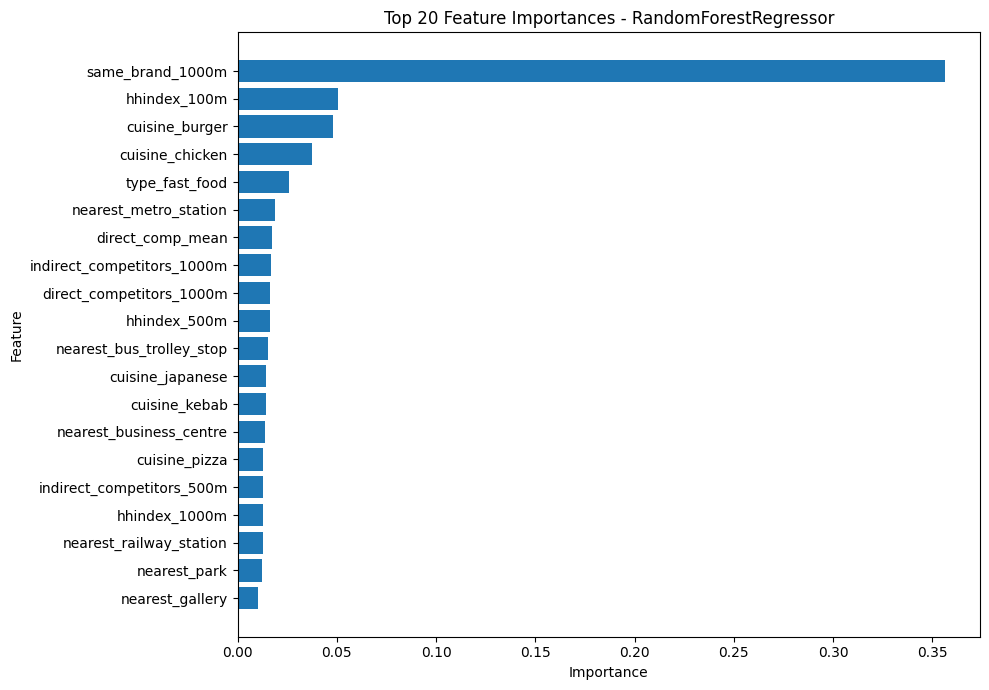

In [ ]:

y = df['log_review_count']
X = df.drop(columns=['dgis_general_rating', 'log_review_count']).copy()
X['log_direct_comp'] = np.log1p(X['direct_competitors_500m'])

X['direct_comp_mean'] = X[
    ['direct_competitors_100m', 'direct_competitors_500m', 'direct_competitors_1000m']
].mean(axis=1)

X['competition_ratio'] = X['direct_competitors_500m'] / (X['indirect_competitors_500m'] + 1)

X['is_centre'] = (X['distance_to_city_centre'] < X['distance_to_city_centre'].median()).astype(int)

X['geo_feature'] = X['lat'] * X['lon']

X = pd.get_dummies(X, columns=['type', 'cuisine', 'city'], drop_first=True)

name_cols = [
    'nearest_museum_name',
    'nearest_theatre_name',
    'nearest_gallery_name',
    'nearest_park_name'
]

for col in name_cols:
    freq_map = X[col].value_counts()
    X[col + '_freq'] = X[col].map(freq_map)

X['website_len'] = X['website'].fillna('').astype(str).apply(len)

X = X.drop(columns=[
    'website',
    'nearest_museum_name',
    'nearest_theatre_name',
    'nearest_gallery_name',
    'nearest_park_name'
], errors='ignore')

for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

X = X.fillna(X.median(numeric_only=True))
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    print("Остались нечисловые колонки, удаляю:", non_numeric_cols)
    X = X.drop(columns=non_numeric_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 8),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestRegressor(**params)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='r2',
        n_jobs=-1
    )

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25, show_progress_bar=True)

print("Лучшие параметры:")
print(study.best_params)

print("\nЛучший CV R2:")
print(study.best_value)

best_params = study.best_params.copy()
best_params['random_state'] = 42
best_params['n_jobs'] = -1

best_model = RandomForestRegressor(**best_params)
best_model.fit(X_train, y_train)

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

def print_metrics(y_true, y_pred, name='dataset'):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f'\nМетрики для {name}:')
    print(f'R2   = {r2:.4f}')
    print(f'RMSE = {rmse:.4f}')
    print(f'MAE  = {mae:.4f}')

print_metrics(y_train, train_pred, 'train')
print_metrics(y_test, test_pred, 'test')
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)

top_20_features = feature_importance_df.head(20).reset_index(drop=True)

print("\nТоп-20 самых важных признаков:")
print(top_20_features)


top_plot = top_20_features.sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_plot['feature'], top_plot['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances - RandomForestRegressor')
plt.tight_layout()
plt.show()